Agentic RAG using LangGraph

In [1]:
print('hello')

hello


In [12]:
import os
from typing import TypedDict , List
from langgraph.graph import StateGraph , END
from langchain_mistralai import MistralAIEmbeddings,ChatMistralAI
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [36]:
from dotenv import load_dotenv
load_dotenv()

os.environ['MISTRAL_API_KEY'] = os.getenv('MISTRAL_API_KEY')

In [37]:
# llm = ChatOpenAI(model='gpt-4.1',temperature=0)
# embeddings = OpenAIEmbeddings()
# llm

llm = ChatMistralAI(model='mistral-large-latest',temperature=0)
embeddings = MistralAIEmbeddings()
llm

ChatMistralAI(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Mistral Large (latest)', 'release_date': '2024-11-01', 'last_updated': '2025-12-02', 'open_weights': True, 'max_input_tokens': 262144, 'max_output_tokens': 262144, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': True, 'temperature': True}, client=<httpx.Client object at 0x00000202DBB8E8C0>, async_client=<httpx.AsyncClient object at 0x00000202DBB8E140>, mistral_api_key=SecretStr('**********'), endpoint='https://api.mistral.ai/v1', model='mistral-large-latest', temperature=0.0, model_kwargs={})

In [81]:
# State Defination

class AgentState(TypedDict):
    question: str
    documents:List[Document]
    answer:str
    needs_retriever:bool

In [82]:
### Sample Documents and Vector Stores

sample_texts = [
    "LangGraph is a stateful, graph-based orchestration framework (built on top of LangChain) designed to build complex, multi-agent, and agentic workflows.",
    "RAG is a technique used to solve an AI's tendency to hallucinate or lack up-to-date knowledge",
    "A Vector DB is a specialized database designed to store, manage, and query information as mathematical representations called embeddings",
    "An AI agent can break down a complex prompt, decide which tools (calculators, web searches, or databases) to use, plan its next steps, and self-correct if it makes a mistake"
]

documents = [Document(page_content=text) for text in sample_texts]

vector_store = FAISS.from_documents(documents,embeddings)
retriever =vector_store.as_retriever(k=3)

In [83]:
# Agent Function

def decide_retrival(state:AgentState) -> AgentState:
    question = state['question']

    # boolean routing to check if it a question
    retrival_keywords = ["what","how","explain","describe","tell me"]
    needs_retriever = any(keyword in question.lower() for keyword in retrival_keywords)

    return {**state,"needs_retriever":needs_retriever}

In [84]:
# retrieve the documents based on the questions

def retrieve_documents(state:AgentState) -> AgentState:
    question = state['question']
    documents = retriever.invoke(question)
    print("Retrieved Docs:", len(documents))

    return {**state , "documents":documents}

In [85]:
ANSWER_PROMPT = """
You are a helpful AI assistant.

Context:
{context}

Question:
{question}

Answer:
"""

In [86]:
# generate the answer

def generate_answer(state:AgentState) -> AgentState:
    question = state['question']
    documents = state.get("documents",[])
    print(documents)

    if documents:
        context = "\n\n".join(
            doc.page_content for doc in documents
        )
        prompt = ANSWER_PROMPT.format(
            context = context,
            question = question
        )
    else:
        prompt = f"""
        Answer the following question directly.
        Question:{question}
        Answer:
        """
    response = llm.invoke(prompt)
    
    return {
        **state,
        "answer":response.content
    }

In [87]:
#Conditional Logic

def should_retrieve(state:AgentState) -> AgentState:
    if state['needs_retriever']:
        return "retrieve"
    else:
        return "generate"

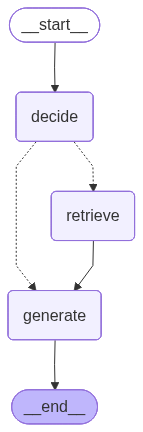

In [88]:
# Buld the Graph

workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("decide",decide_retrival)
workflow.add_node("retrieve",retrieve_documents)
workflow.add_node("generate",generate_answer)

#Set the entry point
workflow.set_entry_point("decide")

# Add conditional edges

workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve":"retrieve",
        "generate":"generate"
    }
)

# add edges
workflow.add_edge("retrieve","generate")
workflow.add_edge("generate",END)

#Compile the graph
app = workflow.compile()
app

In [89]:
#Test the Agentic System
def ask_question(question:str):
    initial_state={
        "question":question,
        "documents":[],
        "answer":"",
        "needs_retriever":False
    }

    result = app.invoke(initial_state)
    return result

In [90]:
q1 = "What is LangGraph?"
r1 = ask_question(q1)
r1
print(r1.keys())
print(r1)

Retrieved Docs: 4
[Document(id='07e1769a-8cb6-4471-887b-3514e970384b', metadata={}, page_content='LangGraph is a stateful, graph-based orchestration framework (built on top of LangChain) designed to build complex, multi-agent, and agentic workflows.'), Document(id='2a128e52-66ae-4ee9-969f-f07bd0ca3c86', metadata={}, page_content='An AI agent can break down a complex prompt, decide which tools (calculators, web searches, or databases) to use, plan its next steps, and self-correct if it makes a mistake'), Document(id='a7dc7f35-6729-4035-ba20-f7cd65a3feb1', metadata={}, page_content="RAG is a technique used to solve an AI's tendency to hallucinate or lack up-to-date knowledge"), Document(id='417b9c37-fcc1-41d6-8f1c-4b29b39a793d', metadata={}, page_content='A Vector DB is a specialized database designed to store, manage, and query information as mathematical representations called embeddings')]
dict_keys(['question', 'documents', 'answer', 'needs_retriever'])
{'question': 'What is LangGrap

In [91]:
q2 = 'Tell me about the RAG?'
r2 = ask_question(q2)
print("Refered Documented :",len(r2['documents']))
print(f"Question:{q2}")
print(f"\nAnswer:{r2['answer']}")

Retrieved Docs: 4
[Document(id='a7dc7f35-6729-4035-ba20-f7cd65a3feb1', metadata={}, page_content="RAG is a technique used to solve an AI's tendency to hallucinate or lack up-to-date knowledge"), Document(id='2a128e52-66ae-4ee9-969f-f07bd0ca3c86', metadata={}, page_content='An AI agent can break down a complex prompt, decide which tools (calculators, web searches, or databases) to use, plan its next steps, and self-correct if it makes a mistake'), Document(id='07e1769a-8cb6-4471-887b-3514e970384b', metadata={}, page_content='LangGraph is a stateful, graph-based orchestration framework (built on top of LangChain) designed to build complex, multi-agent, and agentic workflows.'), Document(id='417b9c37-fcc1-41d6-8f1c-4b29b39a793d', metadata={}, page_content='A Vector DB is a specialized database designed to store, manage, and query information as mathematical representations called embeddings')]
Refered Documented : 4
Question:Tell me about the RAG?

Answer:**Retrieval-Augmented Generation 

In [92]:
q3 = 'Tell me about the Machine Learning'
r3 = ask_question(q3)
print("Refered Documented :",len(r3['documents']))
print(f"Question:{q3}")
print(f"\nAnswer:{r3['answer']}")

Retrieved Docs: 4
[Document(id='2a128e52-66ae-4ee9-969f-f07bd0ca3c86', metadata={}, page_content='An AI agent can break down a complex prompt, decide which tools (calculators, web searches, or databases) to use, plan its next steps, and self-correct if it makes a mistake'), Document(id='a7dc7f35-6729-4035-ba20-f7cd65a3feb1', metadata={}, page_content="RAG is a technique used to solve an AI's tendency to hallucinate or lack up-to-date knowledge"), Document(id='07e1769a-8cb6-4471-887b-3514e970384b', metadata={}, page_content='LangGraph is a stateful, graph-based orchestration framework (built on top of LangChain) designed to build complex, multi-agent, and agentic workflows.'), Document(id='417b9c37-fcc1-41d6-8f1c-4b29b39a793d', metadata={}, page_content='A Vector DB is a specialized database designed to store, manage, and query information as mathematical representations called embeddings')]
Refered Documented : 4
Question:Tell me about the Machine Learning

Answer:Machine Learning (ML)